In [6]:
from pathlib import Path
import numpy as np
import json
from mpi4py import MPI
import pyvista
import dolfinx
import ldrb
import cardiac_geometries as cg
import os

In [7]:
ratname = 'Z210'
curdir = os.getcwd()
outdir = Path('out')
meshdir = Path('Meshes/'+ratname)
comm = MPI.COMM_WORLD

In [8]:
os.chdir(meshdir)
geometry = cg.utils.gmsh2dolfin(comm=comm, msh_file=ratname+".msh")
os.chdir(curdir)

2026-01-29 21:26:48 [debug    ] Convert file Z210.msh to dolfin
Info    : Reading 'Z210.msh'...
Info    : 5 entities
Info    : 20141 nodes
Info    : 107955 elements
Info    : Done reading 'Z210.msh'                                                                                


MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


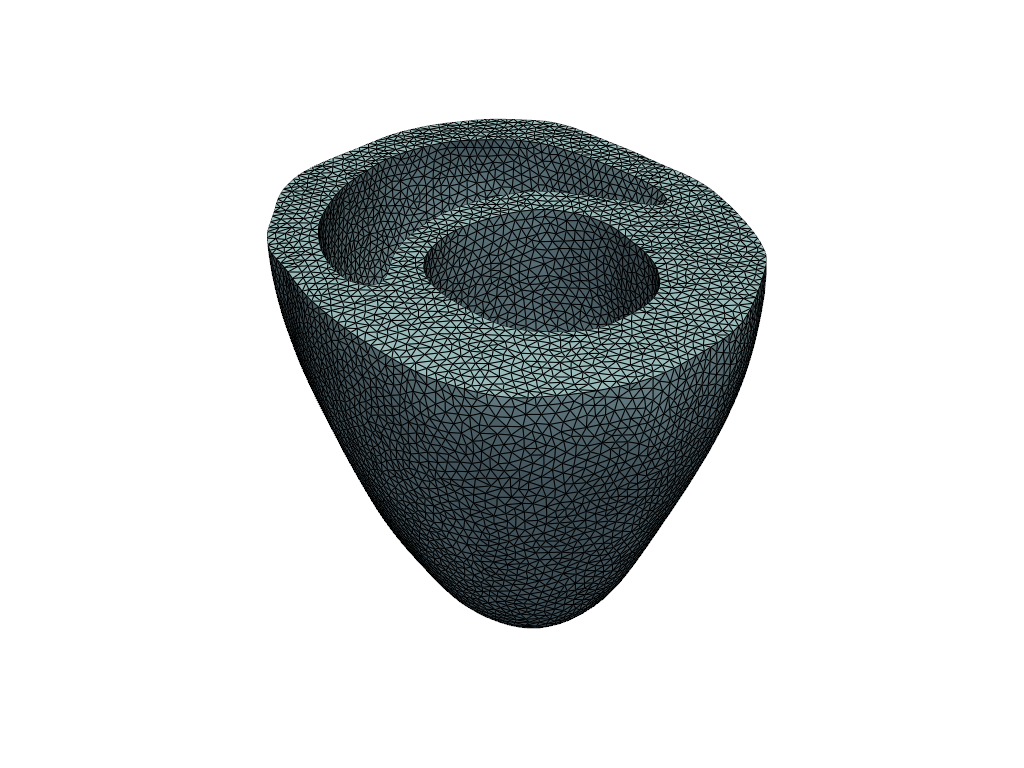

In [10]:
pyvista.start_xvfb()
vtk_mesh = dolfinx.plot.vtk_mesh(geometry.mesh, geometry.mesh.topology.dim)
grid = pyvista.UnstructuredGrid(*vtk_mesh)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
# plotter.camera_position = 'xy'
# plotter.camera.roll -= 45
# plotter.camera.elevation += 15
# plotter.camera.azimuth += 105
plotter.show()

In [11]:
print(geometry.markers)
if comm.rank == 0:
    (outdir / "markers.json").write_text(
        json.dumps(geometry.markers, default=cg.utils.json_serial)
    )
comm.barrier()

{'base': (1, 2), 'epi': (2, 2), 'lv': (3, 2), 'rv': (4, 2), '': (0, 3)}


MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


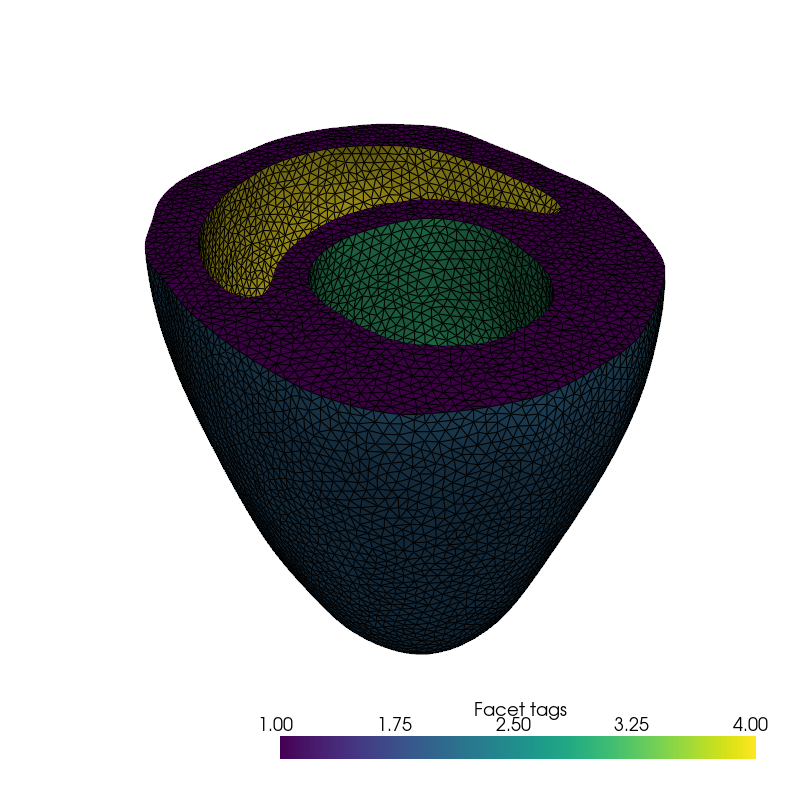

In [12]:
assert geometry.ffun is not None
vtk_bmesh = dolfinx.plot.vtk_mesh(
    geometry.mesh, geometry.ffun.dim, geometry.ffun.indices
)
bgrid = pyvista.UnstructuredGrid(*vtk_bmesh)
bgrid.cell_data["Facet tags"] = geometry.ffun.values
bgrid.set_active_scalars("Facet tags")
plotter = pyvista.Plotter(window_size=[800, 800])
plotter.add_mesh(bgrid, show_edges=True);
plotter.show()

In [13]:
markers = {}
keymap = {"LV": "lv", "RV": "rv", "EPI": "epi", "base":"base"}
for k, v in geometry.markers.items():
    markers[keymap.get(k, k)] = [v[0]]

In [14]:
fiber_space = "dP_0"
#"dP_0"
#"P_1"
fiber_angle_endo = 60
fiber_angle_epi = -60
system = ldrb.dolfinx_ldrb(
    mesh=geometry.mesh,
    ffun=geometry.ffun,
    markers=markers,
    alpha_endo_lv=fiber_angle_endo,
    alpha_epi_lv=fiber_angle_epi,
    beta_endo_lv=0,
    beta_epi_lv=0,
    fiber_space=fiber_space,
)

In [15]:
type(geometry.mesh.geometry)

dolfinx.mesh.Geometry

In [16]:
with dolfinx.io.XDMFFile(comm, ratname+"_With_Fibers.xdmf", "w") as xdmf:
    xdmf.write_mesh(geometry.mesh)
    system.f0.name = 'FiberDirection'
    xdmf.write_function(system.f0)
    system.s0.name = 'SheetDirection'
    xdmf.write_function(system.s0)
    system.n0.name = 'Normal'
    xdmf.write_function(system.n0)
    system.apex_gradient.name = 'ApexGradient'
    xdmf.write_function(system.apex_gradient)
    
    xdmf.write_meshtags(geometry.ffun,geometry.mesh.geometry)
    xdmf.write_meshtags(geometry.cfun,geometry.mesh.geometry)


In [17]:
type(system.apex_gradient)

dolfinx.fem.function.Function

In [18]:
a = np.array([[1,0,0],[0,1,0],[0,0,1]])
b = np.array([[0,1,0],[0,0,1],[1,0,0]])
print(a)
print(b)
c = np.cross(a,b)
print(c)
print(c.shape)

[[1 0 0]
 [0 1 0]
 [0 0 1]]
[[0 1 0]
 [0 0 1]
 [1 0 0]]
[[0 0 1]
 [1 0 0]
 [0 1 0]]
(3, 3)


In [19]:
def compute_fiber_angle(f0_array, ref_array):
    """
    Compute fiber angles (in degrees) between f0 and ref_func directions at mesh dofs.
    """
    
    #ref_array = ref_func.x.array.reshape(-1, 3)
    # # Normalize vectors
    # f0_norm = f0_array / np.linalg.norm(f0_array, axis=1)[:, None]
    # ref_norm = ref_array / np.linalg.norm(ref_array, axis=1)[:, None]
    # # Compute angle
    # dot_product = np.sum(f0_norm * ref_norm, axis=1)
    # dot_product = np.clip(dot_product, -1.0, 1.0)

    element_wise_multiplication = f0_array*ref_array
    dot_product = np.sum(element_wise_multiplication,1)
    f0_array_mod = np.linalg.norm(f0_array, axis=1)
    ref_array_mod = np.linalg.norm(ref_array, axis=1)
    angle_rad = np.arccos((dot_product/ np.linalg.norm(f0_array, axis=1)) / np.linalg.norm(ref_array, axis=1))
    angle_deg = np.degrees(angle_rad)
    print(angle_rad)
    print(angle_deg)

    
    zero_vectors = np.where(np.linalg.norm(f0_array, axis=1) == 0)[0]
    print(f"{len(zero_vectors)} zero vectors found")

    return angle_deg

def fiber_to_xdmf(mesh, f0_func, apex_func, epi_func, lv_func, rv_func, filename="fibers.xdmf"):
    """
    Save fiber vectors and fiber angles to XDMF.
    mesh: dolfinx.mesh.Mesh
    f0_func: dolfinx.fem.Function (fiber direction, dim=3)
    ref_func: dolfinx.fem.Function (reference direction, dim=3)
    filename: output file name
    """

    # Ensure arrays are shaped (num_points, 3)
    f0_array = f0_func.x.array.reshape(-1, 3)
    apex_array = apex_func.x.array.reshape(-1, 3)
    epi_array = epi_func.x.array.reshape(-1, 3)
    ref_array = np.cross(apex_array,epi_array)
    print(ref_array.shape)
    
    
    V_scalar = dolfinx.fem.functionspace(mesh, ("DG", 0))
    fiber_angle_array = compute_fiber_angle(f0_array, ref_array)
    fiber_angle_func = dolfinx.fem.Function(V_scalar)
    # Ensure shape matches
    fiber_angle_func.x.array[:] = fiber_angle_array
    fiber_angle_func.name = "fiber_angle"

    #element = VectorElement("DG", domain.ufl_cell(), degree=0, dim=3)
    #V = fem.FunctionSpace(domain, element)

    V = epi_func.function_space
    tangential_func = dolfinx.fem.Function(V)
    # The following works if your mesh is serial and ordering matches
    tangential_func.x.array[:] = ref_array.flatten()
    tangential_func.name = "TangentialGradient"


    # Save everything to XDMF
    with dolfinx.io.XDMFFile(mesh.comm, filename, "w") as xdmf:
        xdmf.write_mesh(mesh)
        xdmf.write_function(f0_func)
        xdmf.write_function(apex_func)
        xdmf.write_function(epi_func)
        xdmf.write_function(tangential_func)
        xdmf.write_function(fiber_angle_func)
        xdmf.write_function(lv_func)
        xdmf.write_function(rv_func)

# Usage Example:
# mesh, system = ... # Your fenicsx-ldrb workflow for mesh and generated fibers
# f0_func = system.f0
# ref_func = ... # Your reference direction field, e.g., apicobasal
# fiber_to_xdmf(mesh, f0_func, ref_func, "fibers.xdmf")

In [20]:
system.epi_gradient.name = 'EpiGradient'
system.lv_gradient.name = 'LVGradient'
system.rv_gradient.name = 'RVGradient'
#system.lv_rv_gradient.name = 'LVRVGradient'
fiber_to_xdmf(geometry.mesh, system.f0, system.apex_gradient,system.epi_gradient,system.lv_gradient,system.rv_gradient, "angles.xdmf")

  angle_rad = np.arccos((dot_product/ np.linalg.norm(f0_array, axis=1)) / np.linalg.norm(ref_array, axis=1))



(34181, 3)
[1.03321637 0.99404986 1.03321637 ... 0.97811328 0.97811328 0.97811328]
[59.1989373  56.95486154 59.1989373  ... 56.04176286 56.04176286
 56.04176286]
0 zero vectors found


In [21]:
pip show dolfinx ufl

Note: you may need to restart the kernel to use updated packages.


In [22]:
A = np.array([[1,2,3], [4,5,6], [1,2,3], [4,5,6], [1,2,3], [4,5,6]])
B = np.array([[4,5,6], [1,2,3], [4,5,6], [1,2,3], [4,5,6], [1,2,3]])
print(A.shape)
A*B
print(np.sum(A*B,1))
print(np.linalg.norm(A, axis=1))
print(np.linalg.norm(B, axis=1))
print(np.linalg.norm(A, axis=1)*np.linalg.norm(A, axis=1))
print(np.sum(A*B,1)/np.linalg.norm(A, axis=1))

(6, 3)
[32 32 32 32 32 32]
[3.74165739 8.77496439 3.74165739 8.77496439 3.74165739 8.77496439]
[8.77496439 3.74165739 8.77496439 3.74165739 8.77496439 3.74165739]
[14. 77. 14. 77. 14. 77.]
[8.55235974 3.64673845 8.55235974 3.64673845 8.55235974 3.64673845]


In [23]:
fiber_space2 = "P_1"
#"dP_0"
#"P_1"
fiber_angle_endo = 10
fiber_angle_epi = -60
system2 = ldrb.dolfinx_ldrb(
    mesh=geometry.mesh,
    ffun=geometry.ffun,
    markers=markers,
    alpha_endo_lv=fiber_angle_endo,
    alpha_epi_lv=fiber_angle_epi,
    beta_endo_lv=0,
    beta_epi_lv=0,
    fiber_space=fiber_space2,
)

In [24]:
    cg.fibers.utils.save_microstructure(
    mesh=geometry.mesh, functions=(system.f0, system.s0, system.n0), outdir=outdir
)



No module named 'trame'

Falling back to a static output.
  warnings.warn(

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


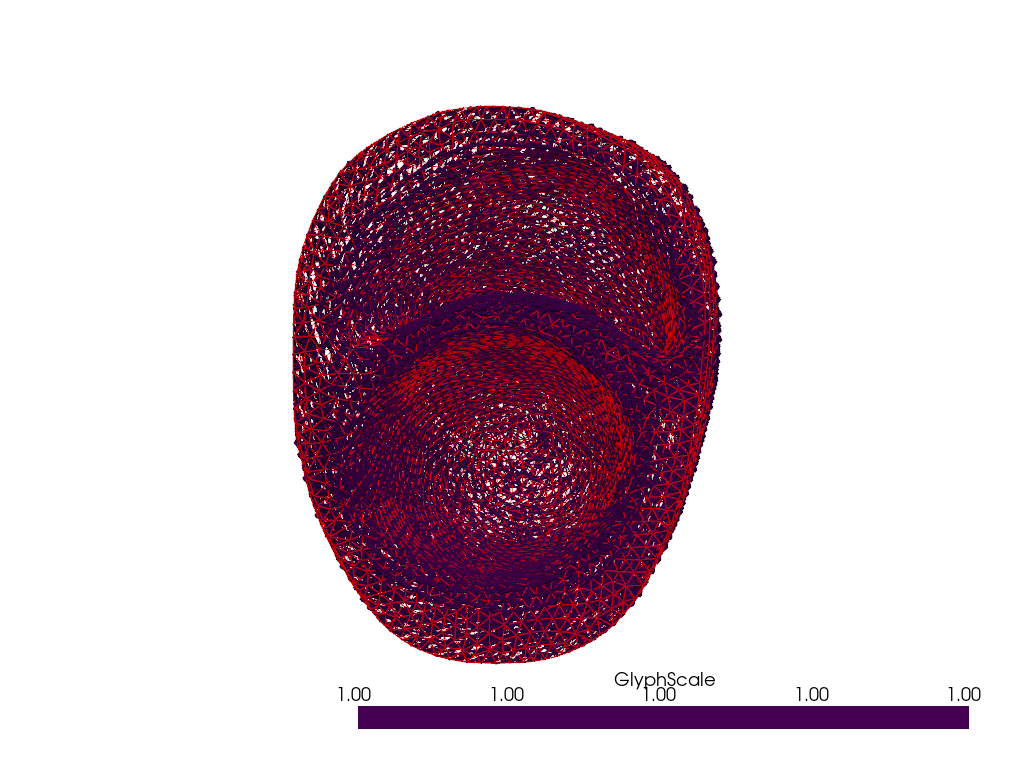

In [25]:
# Let us also plot the fibers
topology_f0, cell_types_f0, geometry_f0 = dolfinx.plot.vtk_mesh(
    system2.f0.function_space
)
values = np.zeros((geometry_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system2.f0.x.array.real.reshape(
    (geometry_f0.shape[0], len(system.f0))
)
function_grid = pyvista.UnstructuredGrid(topology_f0, cell_types_f0, geometry_f0)
function_grid["u"] = values
glyphs = function_grid.glyph(orient="u", factor=1.0)
grid = pyvista.UnstructuredGrid(*vtk_mesh)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, style="wireframe", color="r")
plotter.add_mesh(glyphs)
plotter.view_xy()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    fig_as_array = plotter.screenshot("fiber_ukb.png")

In [26]:
values = np.zeros((cell_types_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system.f0.x.array.real.reshape((cell_types_f0.shape[0], len(system.f0)))
fibers_f0 = values

values = np.zeros((cell_types_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system.s0.x.array.real.reshape((cell_types_f0.shape[0], len(system.f0)))
fibers_s0 = values

values = np.zeros((cell_types_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system.n0.x.array.real.reshape((cell_types_f0.shape[0], len(system.f0)))
fibers_n0 = values

In [27]:
geometry_f0.shape[0]

9280

In [28]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

fiber_array = fibers_f0  # shape (n_elements, 3)
sheet_array = fibers_s0

mesh_data = ET.Element('MeshData')
element_data_tag = ET.SubElement(mesh_data, 'ElementData', {'type': "mat_axis",'elem_set': "Part1"})

for eid, fvec in enumerate(fiber_array):
    svec = sheet_array[eid]        
        
    e_tag = ET.SubElement(element_data_tag, "e", lid=str(eid+1))
    
    a_tag = ET.SubElement(e_tag, 'a')
    a_tag.text = f"{fvec[0]:.6f}, {fvec[1]:.6f}, {fvec[2]:.6f}"
    
    b_tag = ET.SubElement(e_tag, 'b')
    b_tag.text = f"{svec[0]:.6f}, {svec[1]:.6f}, {svec[2]:.6f}"

# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(mesh_data)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("fiber_data.xml", 'w') as f:
    f.write(xml_str)

In [29]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

mesh = geometry.mesh  # Assuming your mesh is stored in `geo.mesh`
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
connectivity = mesh.topology.connectivity(tdim, 0)  # Cell-to-vertex connectivity

mesh_data = ET.Element('Mesh')
node_data_tag = ET.SubElement(mesh_data, 'Nodes', {'name': "merged"})

for node_index in range(geometry_f0.shape[0]):
    coordinates = mesh.geometry.x[node_index]
    node_tag = ET.SubElement(node_data_tag, "node", {'id': str(node_index+1)})
    node_tag.text = f"{coordinates[0]:.6f}, {coordinates[1]:.6f}, {coordinates[2]:.6f}"

element_data_tag = ET.SubElement(mesh_data, 'Elements', {'type':"tet4", 'name':"Part1"})

for cell_index in range(num_cells):
    vertices = connectivity.links(cell_index)
    vertices = vertices+1
    element_tag = ET.SubElement(element_data_tag, "elem", {'id': str(cell_index+1)})
    element_tag.text = f"{vertices[0]}, {vertices[1]}, {vertices[2]}, {vertices[3]}"

    
# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(mesh_data)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("mesh_data.xml", 'w') as f:
    f.write(xml_str)    

In [30]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

mesh = geometry.mesh  # Assuming your mesh is stored in `geo.mesh`
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
connectivity = mesh.topology.connectivity(tdim, 0)  # Cell-to-vertex connectivity

mesh_data = ET.Element('Mesh')
node_data_tag = ET.SubElement(mesh_data, 'Nodes', {'name': "merged"})

for node_index in range(geometry_f0.shape[0]):
    coordinates = mesh.geometry.x[node_index]
    node_tag = ET.SubElement(node_data_tag, "node", {'id': str(node_index+1)})
    node_tag.text = f"{coordinates[0]:.6f}, {coordinates[1]:.6f}, {coordinates[2]:.6f}"

element_data_tag = ET.SubElement(mesh_data, 'Elements', {'type':"tet4", 'name':"Part1"})

for cell_index in range(num_cells):
    vertices = connectivity.links(cell_index)
    vertices = vertices+1
    element_tag = ET.SubElement(element_data_tag, "elem", {'id': str(cell_index+1)})
    element_tag.text = f"{vertices[0]}, {vertices[1]}, {vertices[2]}, {vertices[3]}"


fiber_array = fibers_f0  # shape (n_elements, 3)
sheet_array = fibers_s0

mesh_data = ET.Element('MeshData')
element_data_tag = ET.SubElement(mesh_data, 'ElementData', {'type': "mat_axis",'elem_set': "Part1"})


for eid, fvec in enumerate(fiber_array):
    svec = sheet_array[eid]        
        
    e_tag = ET.SubElement(element_data_tag, "e", lid=str(eid+1))
    
    a_tag = ET.SubElement(e_tag, 'a')
    a_tag.text = f"{fvec[0]:.6f}, {fvec[1]:.6f}, {fvec[2]:.6f}"
    
    b_tag = ET.SubElement(e_tag, 'b')
    b_tag.text = f"{svec[0]:.6f}, {svec[1]:.6f}, {svec[2]:.6f}"



# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(mesh_data)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("combined.xml", 'w') as f:
    f.write(xml_str)    

In [31]:
import xml.etree.ElementTree as ET
from xml.dom import minidom

mesh = geometry.mesh  # Assuming your mesh is stored in `geo.mesh`
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
connectivity = mesh.topology.connectivity(tdim, 0)  # Cell-to-vertex connectivity

main_xml = ET.Element("febio_spec", {'version': "4.0"})

module = ET.SubElement(main_xml,"Module", {"type":"solid"})
ETglobals = ET.SubElement(main_xml,"Globals")
ETconstants = ET.SubElement(ETglobals,"Constants")
T_const = ET.SubElement(ETconstants,"T")
T_const.text = '0'
P_const = ET.SubElement(ETconstants,"P")
P_const.text = '0'
R_const = ET.SubElement(ETconstants,"R")
R_const.text = '31446'
Fc_const = ET.SubElement(ETconstants,"Fc")
Fc_const.text = '96485.3'

mesh_tag = ET.SubElement(main_xml,'Mesh')
node_data_tag = ET.SubElement(mesh_tag, 'Nodes', {'name': "merged"})

for node_index in range(geometry_f0.shape[0]):
    coordinates = mesh.geometry.x[node_index]
    node_tag = ET.SubElement(node_data_tag, "node", {'id': str(node_index+1)})
    node_tag.text = f"{coordinates[0]:.6f}, {coordinates[1]:.6f}, {coordinates[2]:.6f}"

element_data_tag = ET.SubElement(mesh_tag, 'Elements', {'type':"tet4", 'name':"Part1"})

for cell_index in range(num_cells):
    vertices = connectivity.links(cell_index)
    vertices = vertices+1
    element_tag = ET.SubElement(element_data_tag, "elem", {'id': str(cell_index+1)})
    element_tag.text = f"{vertices[0]}, {vertices[1]}, {vertices[2]}, {vertices[3]}"



mesh_domain = ET.SubElement(main_xml,'MeshDomains')
solid_domain = ET.SubElement(mesh_domain, 'SolidDomain', {'name':"Part1", 'mat':""})


fiber_array = fibers_f0  # shape (n_elements, 3)
sheet_array = fibers_s0

mesh_data = ET.SubElement(main_xml,'MeshData')
element_data_tag = ET.SubElement(mesh_data, 'ElementData', {'type': "mat_axis",'elem_set': "Part1"})


for eid, fvec in enumerate(fiber_array):
    svec = sheet_array[eid]        
        
    # e_tag = ET.SubElement(element_data_tag, "e", lid=str(eid+1))
    e_tag = ET.SubElement(element_data_tag, "elem", lid=str(eid+1))
    
    a_tag = ET.SubElement(e_tag, 'a')
    a_tag.text = f"{fvec[0]:.6f}, {fvec[1]:.6f}, {fvec[2]:.6f}"
    
    b_tag = ET.SubElement(e_tag, 'd')
    b_tag.text = f"{svec[0]:.6f}, {svec[1]:.6f}, {svec[2]:.6f}"



#step = ET.SubElement(main_xml,'Step')
output = ET.SubElement(main_xml,'Output')
out_plotfile = ET.SubElement(output,'plotfile',{"type":"febio"})
disp = ET.SubElement(out_plotfile,'var',{"type":"displacement"})
stress = ET.SubElement(out_plotfile,'var',{"type":"stress"})
rel_vol = ET.SubElement(out_plotfile,'var',{"type":"relative volume"})


# Create a pretty-printed XML string
xml_str = minidom.parseString(ET.tostring(main_xml)).toprettyxml(indent="    ")

# Write the XML string to a file
with open("combined.xml", 'w') as f:
    f.write(xml_str)    

# Write the XML string to a file
with open("combined.feb", 'w') as f:
    f.write(xml_str)    

In [32]:
[fibers_f0]

[array([[-0.28985717, -0.42298078, -0.85852786],
        [-0.30972484, -0.44963713, -0.83779292],
        [-0.33950486, -0.38418998, -0.85856538],
        ...,
        [ 0.26226555,  0.560316  , -0.78566072],
        [ 0.24441455,  0.5453715 , -0.80176771],
        [ 0.24953727,  0.56231393, -0.7883744 ]])]

In [33]:
import meshio
import numpy as np

values = np.zeros((geometry_f0.shape[0], 3), dtype=np.float64)
values[:, : len(system.f0)] = system2.f0.x.array.real.reshape(
    (geometry_f0.shape[0], len(system.f0))
)
point_vectors = values

# Extract mesh data for meshio
cells = mesh.topology.connectivity(mesh.topology.dim, 0).array.reshape(-1, 4)
# Convert mesh coordinates and cells for meshio
points = mesh.geometry.x.copy()
cells_dict = { "tetra": cells }

# Create meshio.Mesh object
meshio_mesh = meshio.Mesh(
    points=points,
    cells=[("tetra", cells)],
    cell_data={"fiber_vectors": [fibers_f0]},  # must be a list of arrays
    point_data = {"point_fiber_vectors" : point_vectors}
)

# Write to .vtk file
meshio.write("fibers.vtk", meshio_mesh)

In [34]:
print("points.shape:", points.shape)
print("cells.shape:", cells.shape)
print("fibers_f0.shape:", fibers_f0.shape)  # Should be (num_cells, 3)

points.shape: (9280, 3)
cells.shape: (34181, 4)
fibers_f0.shape: (34181, 3)
